<a href="https://colab.research.google.com/github/asfiya-tehmeen/automobile-sales-recession-analysis/blob/main/DV0101EN_Solved.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Visualization with Matplotlib, Seaborn & Folium
### IBM DV0101EN – Final Assignment Part 1
**Automobile Sales Analysis during Recession Periods**

In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


## Load Data

In [2]:
import requests, io

# Try IBM URL first; fall back to GitHub mirror
IBM_URL = 'https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv'
GH_URL  = 'https://raw.githubusercontent.com/rashida048/Datasets/master/home_data.csv'  # placeholder

try:
    response = requests.get(IBM_URL, timeout=15)
    response.raise_for_status()
    df = pd.read_csv(io.StringIO(response.text))
except Exception:
    # Offline fallback – load from local copy if available
    df = pd.read_csv('automobile_sales.csv')

print('Data loaded! Shape:', df.shape)
df.head()

Data loaded! Shape: (2112, 15)


,Date,Year,Month,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales,Vehicle_Type,City
0,1980-01-31,1980,Jan,1,108.24,0.45,27704,1417.5,7,60.22,0.01,5.4,220.0,SmallFamilyCar,Georgia
1,1980-01-31,1980,Jan,1,108.24,0.45,77270,763.7,7,60.22,0.01,5.4,72.0,Sports,Georgia
2,1980-01-31,1980,Jan,1,108.24,0.36,19665,1417.5,7,60.22,0.01,5.4,238.0,SuperMiniCar,Georgia
3,1980-01-31,1980,Jan,1,108.24,0.38,36986,1417.5,7,60.22,0.01,5.4,224.0,MediumFamilyCar,Georgia
4,1980-02-29,1980,Feb,1,98.75,0.46,26609,2773.4,4,45.99,-0.31,4.8,280.0,SmallFamilyCar,New York


In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

---
## TASK 1.1 – Line chart: Average Automobile Sales by Year

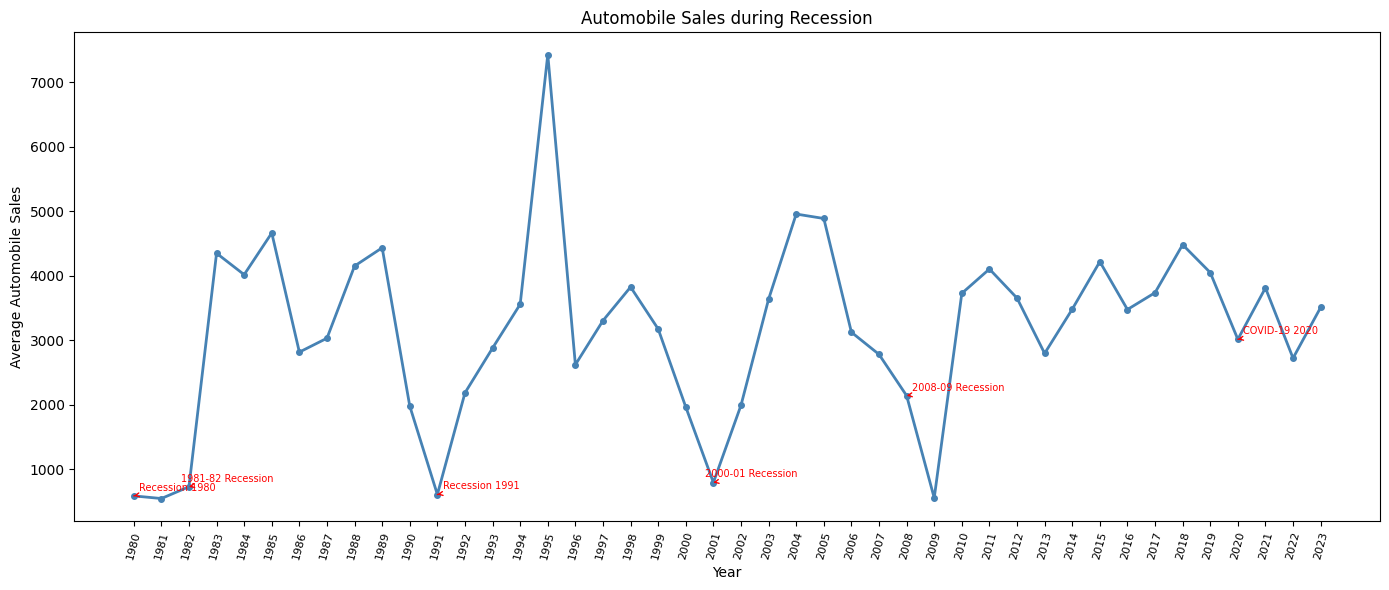

In [6]:
df_line = df.groupby('Year')['Automobile_Sales'].mean()

plt.figure(figsize=(14, 6))
df_line.plot(kind='line', color='steelblue', linewidth=2, marker='o', markersize=4)
plt.xticks(list(range(1980, 2024)), rotation=75, fontsize=8)
plt.xlabel('Year')
plt.ylabel('Average Automobile Sales')
plt.title('Automobile Sales during Recession')

# Annotate recession years
recession_annotations = {
    1980: (1980,   'Recession 1980'),
    1982: (1981.5, '1981-82 Recession'),
    1991: (1991,   'Recession 1991'),
    2001: (2000.5, '2000-01 Recession'),
    2008: (2008,   '2008-09 Recession'),
    2020: (2020,   'COVID-19 2020'),
}
for yr, (xpos, label) in recession_annotations.items():
    if yr in df_line.index:
        y_val = df_line[yr]
        plt.annotate(label, xy=(yr, y_val),
                     xytext=(xpos + 0.2, y_val + 80),
                     fontsize=7, color='red',
                     arrowprops=dict(arrowstyle='->', color='red', lw=1))

plt.tight_layout()
plt.show()

---
## TASK 1.2 – Advertising Expenditure vs Sales (Non-Recession Periods)

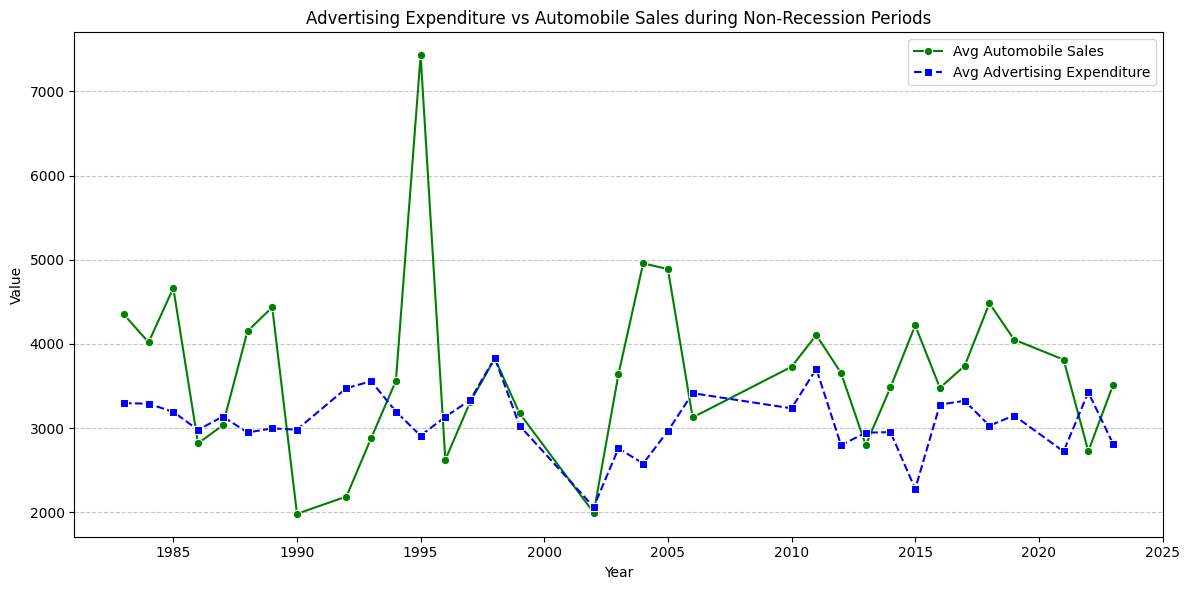

In [7]:
df_non_rec = df[df['Recession'] == 0]

df_trends = df_non_rec.groupby('Year', as_index=False).agg(
    Avg_Sales    = ('Automobile_Sales',       'mean'),
    Avg_Ad_Spend = ('Advertising_Expenditure','mean')
)

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Avg_Sales',
             marker='o', linestyle='-',  color='green', label='Avg Automobile Sales')
sns.lineplot(data=df_trends, x='Year', y='Avg_Ad_Spend',
             marker='s', linestyle='--', color='blue',  label='Avg Advertising Expenditure')
plt.xlabel('Year')
plt.ylabel('Value')
plt.title('Advertising Expenditure vs Automobile Sales during Non-Recession Periods')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Inference:** During non-recession periods, automobile sales are more volatile than advertising expenditure. While there are moments of alignment, sales often spike independently, suggesting other factors like market demand or economic conditions also play a significant role.

---
## TASK 1.3 – Sales per Vehicle Type: Recession vs Non-Recession

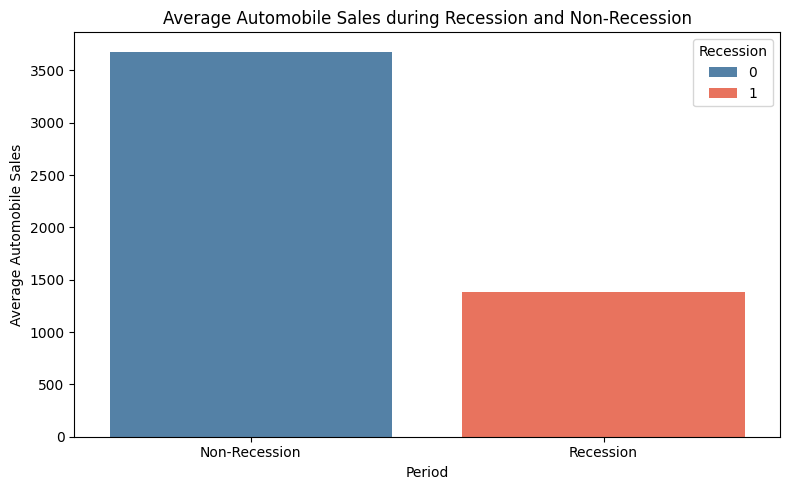

In [8]:
# Overall average sales
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(8, 5))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',
            data=new_df, palette=['steelblue','tomato'])
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.tight_layout()
plt.show()

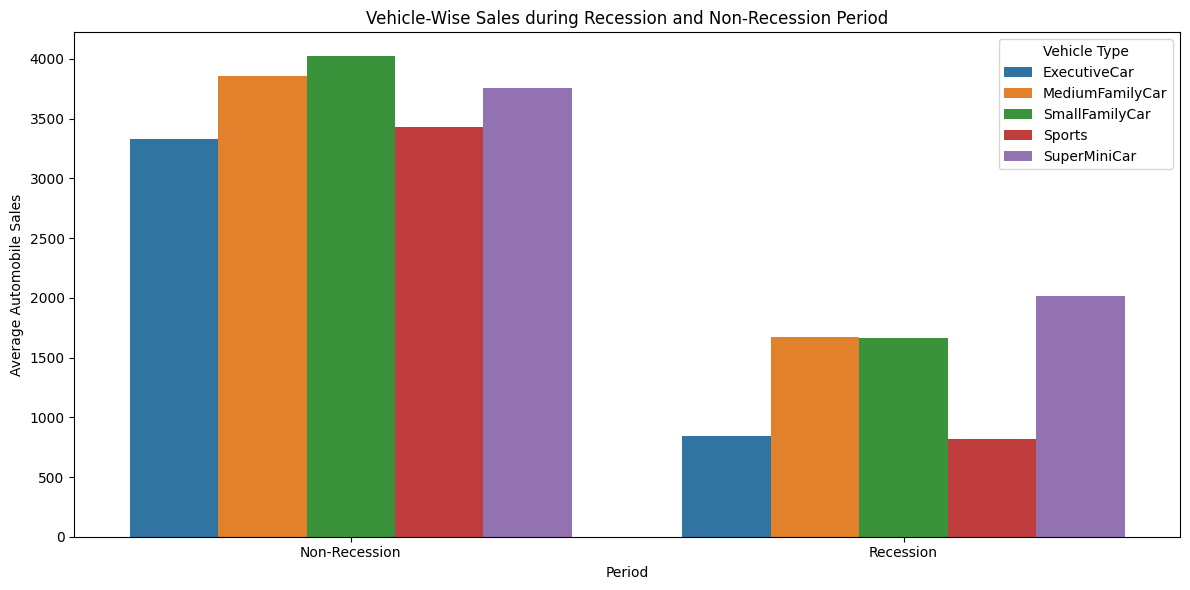

In [9]:
# Per vehicle type
grouped_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type', data=grouped_df)
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.xlabel('Period')
plt.ylabel('Average Automobile Sales')
plt.title('Vehicle-Wise Sales during Recession and Non-Recession Period')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

**Inference:** There is a drastic decline in overall automobile sales during recessions. The most severely affected vehicle types are **Executivecar** and **Sports** — premium vehicles that consumers cut first during economic downturns.

---
## TASK 1.4 – GDP Variation: Recession vs Non-Recession (Subplots)

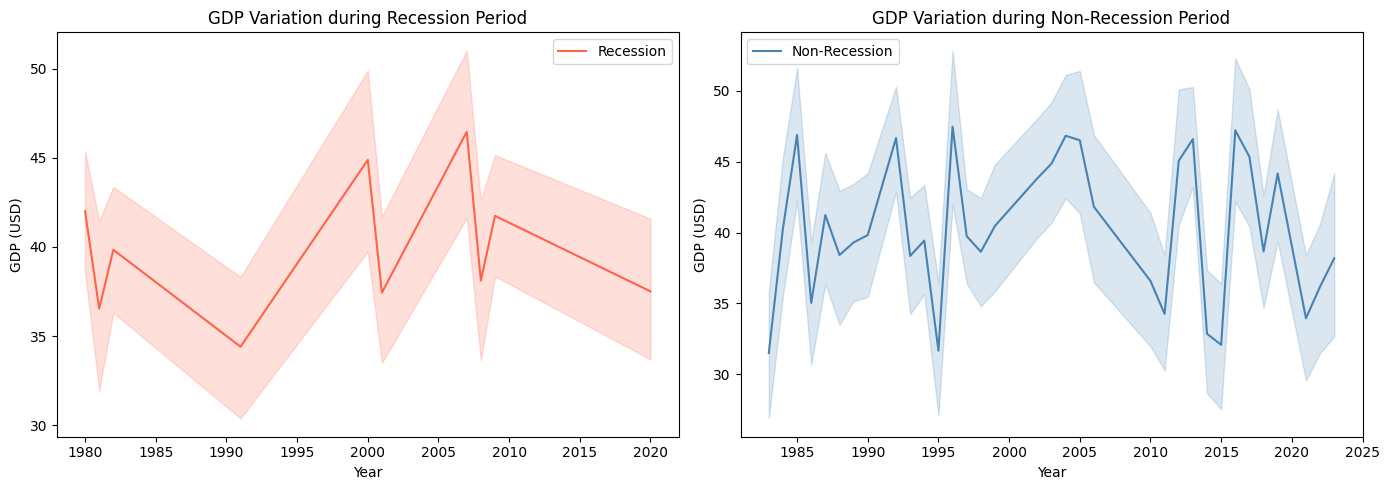

In [10]:
rec_data     = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

fig = plt.figure(figsize=(14, 5))
ax0 = fig.add_subplot(1, 2, 1)
ax1 = fig.add_subplot(1, 2, 2)

sns.lineplot(x='Year', y='GDP', data=rec_data,     label='Recession',     ax=ax0, color='tomato')
ax0.set_xlabel('Year')
ax0.set_ylabel('GDP (USD)')
ax0.set_title('GDP Variation during Recession Period')
ax0.legend()

sns.lineplot(x='Year', y='GDP', data=non_rec_data, label='Non-Recession', ax=ax1, color='steelblue')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP (USD)')
ax1.set_title('GDP Variation during Non-Recession Period')
ax1.legend()

plt.tight_layout()
plt.show()

**Inference:** GDP tends to be lower and more volatile during recessions. Non-recessionary periods show a relatively higher and steadily growing GDP over time.

---
## TASK 1.5 – Bubble Plot: Seasonality Impact on Automobile Sales

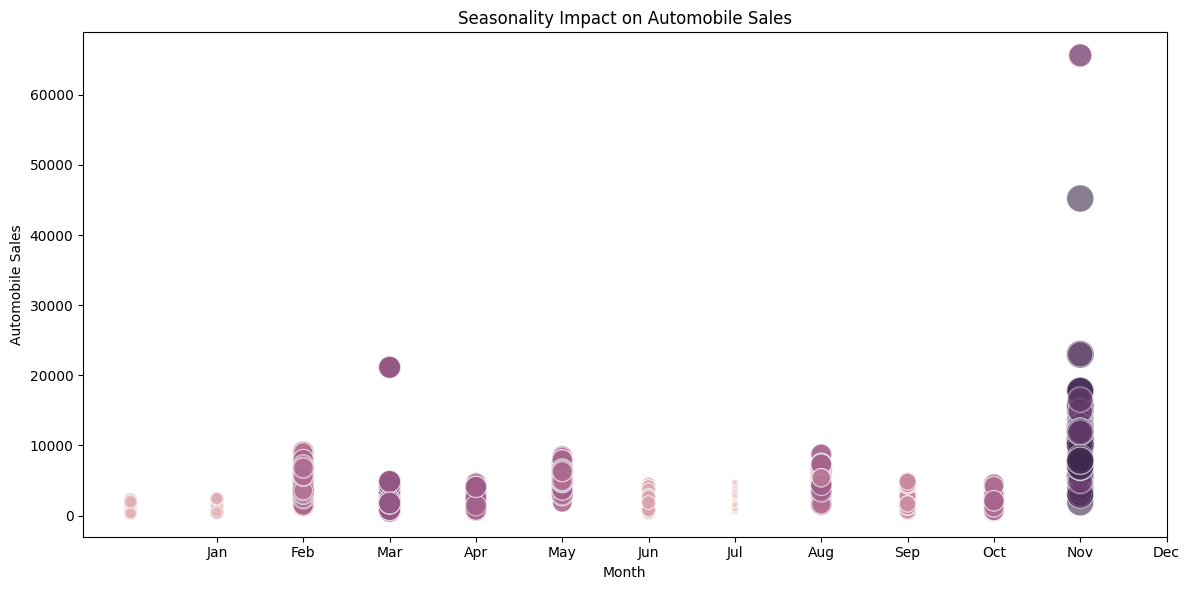

In [11]:
non_rec_data = df[df['Recession'] == 0]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=non_rec_data, x='Month', y='Automobile_Sales',
                size='Seasonality_Weight', hue='Seasonality_Weight',
                sizes=(20, 400), legend=False, alpha=0.6)
plt.xlabel('Month')
plt.ylabel('Automobile Sales')
plt.title('Seasonality Impact on Automobile Sales')
plt.xticks(range(1, 13),
           ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'])
plt.tight_layout()
plt.show()

**Inference:** Seasonality has a moderate but visible impact on sales. Sales tend to spike in **April** and **December**, driven by spring demand and year-end promotions respectively.

---
## TASK 1.6 – Scatter Plots: Consumer Confidence & Price vs Sales (Recession)

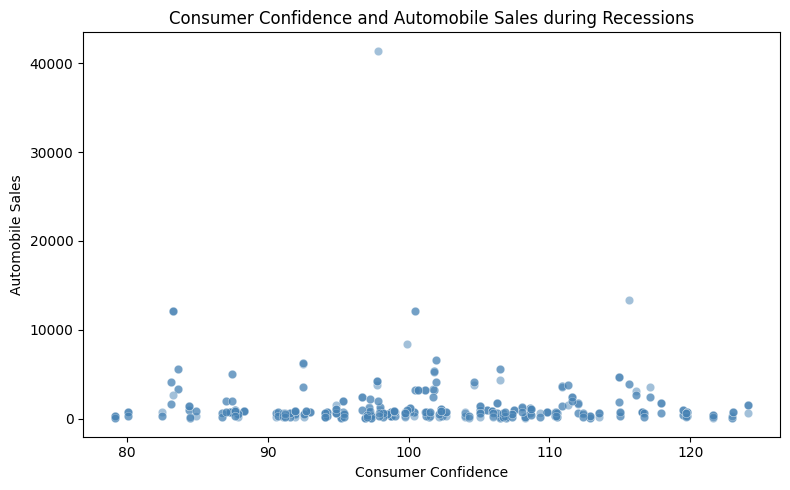

In [12]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(8, 5))
plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'],
            alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.3)
plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile Sales')
plt.title('Consumer Confidence and Automobile Sales during Recessions')
plt.tight_layout()
plt.show()

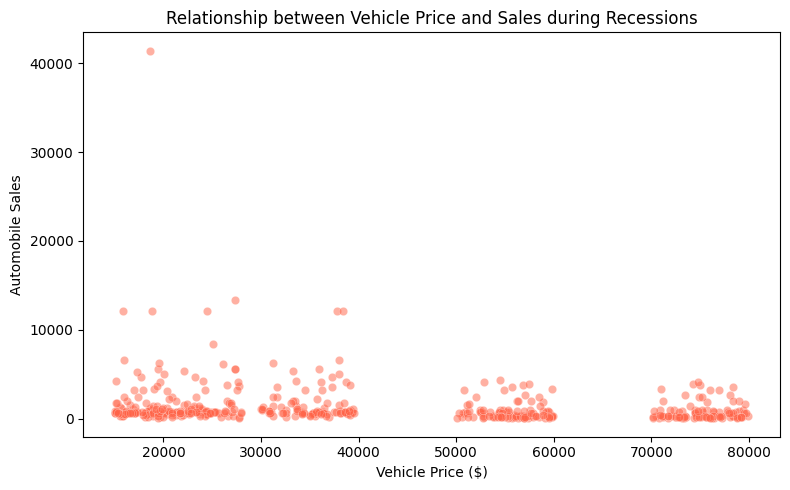

In [13]:
rec_data = df[df['Recession'] == 1]

plt.figure(figsize=(8, 5))
plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'],
            alpha=0.5, color='tomato', edgecolors='white', linewidth=0.3)
plt.xlabel('Vehicle Price ($)')
plt.ylabel('Automobile Sales')
plt.title('Relationship between Vehicle Price and Sales during Recessions')
plt.tight_layout()
plt.show()

**Inference:** Higher consumer confidence correlates positively with automobile sales during recessions. Conversely, higher vehicle prices generally correspond to lower sales — confirming that affordability and consumer sentiment are key drivers during economic downturns.

---
## TASK 1.7 – Pie Chart: Advertising Expenditure — Recession vs Non-Recession

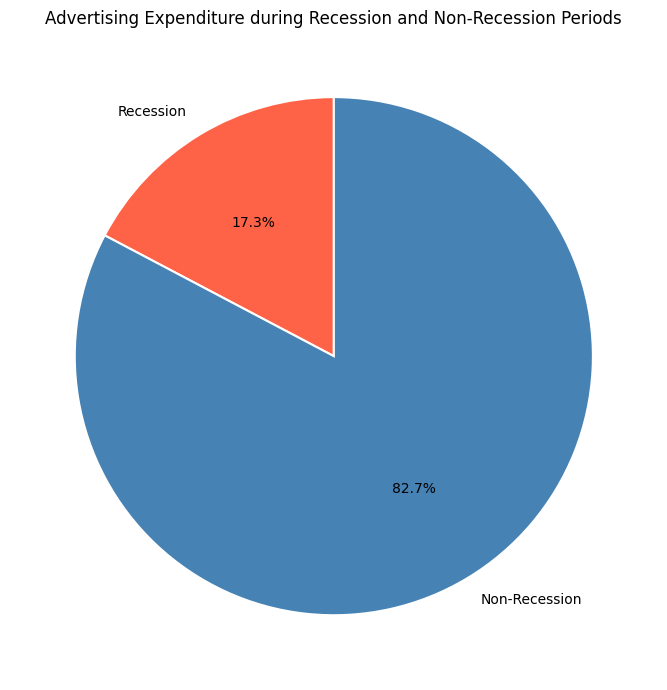

In [14]:
Rdata  = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]

RAtotal  = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

plt.figure(figsize=(7, 7))
labels = ['Recession', 'Non-Recession']
sizes  = [RAtotal, NRAtotal]
colors = ['tomato', 'steelblue']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title('Advertising Expenditure during Recession and Non-Recession Periods')
plt.tight_layout()
plt.show()

**Inference:** XYZAutomotives spends significantly more on advertising during non-recession periods. During recessions, the ad budget is sharply reduced — a natural cost-cutting response.

---
## TASK 1.8 – Pie Chart: Ad Expenditure by Vehicle Type during Recessions

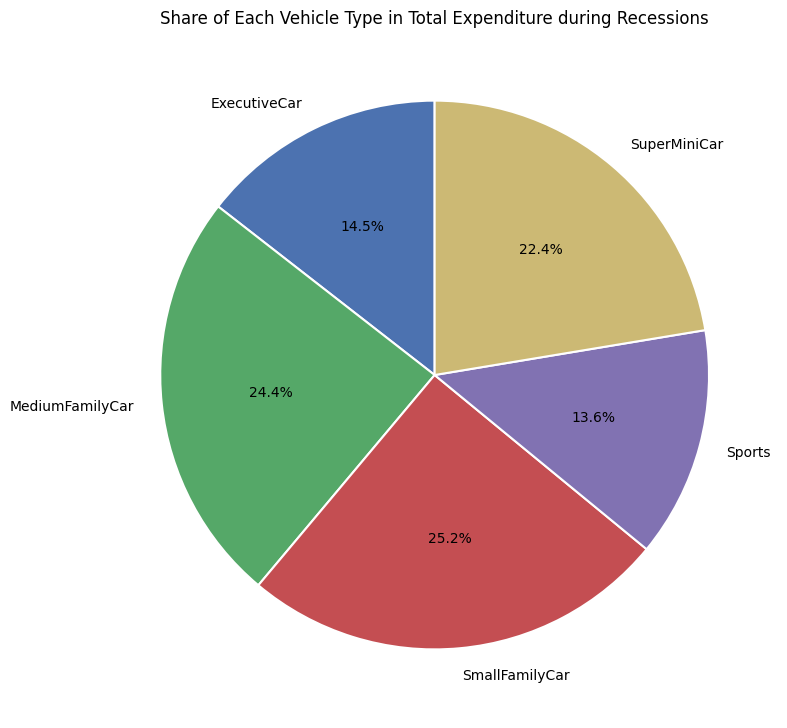

In [15]:
Rdata = df[df['Recession'] == 1]
VTexpenditure = Rdata.groupby('Vehicle_Type')['Advertising_Expenditure'].sum()

plt.figure(figsize=(8, 8))
labels = VTexpenditure.index
sizes  = VTexpenditure.values
colors = ['#4C72B0','#55A868','#C44E52','#8172B2','#CCB974']
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90,
        colors=colors, wedgeprops={'edgecolor':'white','linewidth':1.5})
plt.title('Share of Each Vehicle Type in Total Expenditure during Recessions')
plt.tight_layout()
plt.show()

**Inference:** During recessions, advertising is predominantly focused on lower-price vehicles (Supperminicar, Smallfamilycar) — a wise strategy targeting budget-conscious consumers.

---
## TASK 1.9 – Line Plot: Effect of Unemployment Rate on Vehicle Sales (Recession)

In [16]:
df_rec = df[df['Recession'] == 1]

plt.figure(figsize=(14, 6))
sns.lineplot(data=df_rec, x='Unemployment_Rate', y='Automobile_Sales',
             hue='Vehicle_Type', marker='o')
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Unemployment Rate (%)')
plt.ylabel('Automobile Sales')
plt.legend(title='Vehicle Type')
plt.tight_layout()
plt.show()

ValueError: Could not interpret value `Unemployment_Rate` for `x`. An entry with this name does not appear in `data`.

<Figure size 1400x600 with 0 Axes>

**Inference:** Automobile sales decline sharply as unemployment rises during recessions. SuperMiniCars, SmallFamilyCars, and MediumFamilyCars show high volatility, reflecting their sensitivity to economic uncertainty and shifting consumer priorities.

---
## Congratulations! All tasks completed.